### DreamCatcher: The Project ###

This will eventually be the introduction.

#### The goal of the project is to: ####
Build a working pipeline that:
1. Loads dream narratives
2. cleans text
3. converts each dream to an embediing (semantic vector)
4. clusters dreams (unsupervised)
5. visualizes the "dream universe" with UMAP
6. summarizes clusters with keywords + example dreams

In [2]:
# Imports needed for the project

from pathlib import Path

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

import umap
import hdbscan

import nltk
from nltk.corpus import stopwords

from sentence_transformers import SentenceTransformer

In [3]:
nltk.download("stopwords")
STOPWORDS = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jebri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
DATA_PATH = Path("Data/dreamsearch.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,Dream Report ID,Title,Dream Text,Participant ID,Gender,Age,Word Count,Dream Date,Survey Name,Survey ID,Question,Categories
0,0192a1a8-b8b4-7cef-9f50-520dc2d4e4a4,NaN,Mostly forgotten. Flying across an extensive p...,Melvin,NaN,NaN,78,12/4/2022,melvin-dreams,0192a1a8-b862-73e6-91fd-bb6a7b2e39c8,Last Night's Dream,NaN
1,0192a1a8-b8b4-7cef-9f50-520dc2f55d92,NaN,Beginning forgotten. An alternative school cla...,Melvin,NaN,NaN,329,12/7/2022,melvin-dreams,0192a1a8-b862-73e6-91fd-bb6a7b2e39c8,Last Night's Dream,NaN
2,0192a1a8-b8b4-7cef-9f50-520dc317f5c7,NaN,"A lot of Mexican, Hispanic, boys. A school sit...",Melvin,NaN,NaN,128,12/7/2022,melvin-dreams,0192a1a8-b862-73e6-91fd-bb6a7b2e39c8,Last Night's Dream,NaN
3,0192a1a8-b8b4-7cef-9f50-520dc33a777a,NaN,"Danny. Before this there was a long bit, mostl...",Melvin,NaN,NaN,291,12/8/2022,melvin-dreams,0192a1a8-b862-73e6-91fd-bb6a7b2e39c8,Last Night's Dream,NaN
4,0192a1a8-b8b4-7cef-9f50-520dc368d951,NaN,North side of Queen Sarah Johnson. Not so much...,Melvin,NaN,NaN,518,12/9/2022,melvin-dreams,0192a1a8-b862-73e6-91fd-bb6a7b2e39c8,Last Night's Dream,NaN


In [5]:
df.columns

Index(['Dream Report ID', 'Title', 'Dream Text', 'Participant ID', 'Gender',
       'Age', 'Word Count', 'Dream Date', 'Survey Name', 'Survey ID',
       'Question', 'Categories'],
      dtype='str')

In [6]:
# Columns we will be working with

MODEL_COLS = [
    "Dream Report ID",
    "Dream Text",
    "Word Count",
    "Participant ID",
    "Dream Date",
    "Age",
    "Gender"
]

df_model = df[MODEL_COLS].copy()
df_model.head()

,Dream Report ID,Dream Text,Word Count,Participant ID,Dream Date,Age,Gender
0,0192a1a8-b8b4-7cef-9f50-520dc2d4e4a4,Mostly forgotten. Flying across an extensive p...,78,Melvin,12/4/2022,NaN,NaN
1,0192a1a8-b8b4-7cef-9f50-520dc2f55d92,Beginning forgotten. An alternative school cla...,329,Melvin,12/7/2022,NaN,NaN
2,0192a1a8-b8b4-7cef-9f50-520dc317f5c7,"A lot of Mexican, Hispanic, boys. A school sit...",128,Melvin,12/7/2022,NaN,NaN
3,0192a1a8-b8b4-7cef-9f50-520dc33a777a,"Danny. Before this there was a long bit, mostl...",291,Melvin,12/8/2022,NaN,NaN
4,0192a1a8-b8b4-7cef-9f50-520dc368d951,North side of Queen Sarah Johnson. Not so much...,518,Melvin,12/9/2022,NaN,NaN


In [7]:
# renaming columns for cleaner convension

df_model = df_model.rename(columns={
    "Dream Report ID": "dream_id",
    "Dream Text": "text",
    "Word Count": "word_count",
    "Participant ID": "participant_id",
    "Dream Date": "date"
})

In [8]:
df_model.columns

Index(['dream_id', 'text', 'word_count', 'participant_id', 'date', 'Age',
       'Gender'],
      dtype='str')

In [9]:
# This shows the proportion of missing values per column. We only need text for phase 1 of this project, but maybe adding a different dataset later will provide us demographic information for further analysis 

df_model.isna().mean().sort_values(ascending=False)

Gender            1.000000
Age               1.000000
text              0.035169
participant_id    0.003232
dream_id          0.000000
word_count        0.000000
date              0.000000
dtype: float64

In [10]:
# filtering

df_model = df_model.dropna(subset=["text"]) #just incase, if we add more data in the future
df_model.shape

(42989, 7)

In [11]:
df_model["word_count"].describe()

count    42989.000000
mean       104.363000
std        159.456313
min          1.000000
25%         16.000000
50%         58.000000
75%        125.000000
max       2681.000000
Name: word_count, dtype: float64

In [12]:
MIN_WORDS = 20

df_model = df_model[df_model["word_count"] >= MIN_WORDS].copy()
df_model.shape

(31200, 7)

Short dream narratives lack sufficient semantic context for embedding based clustering. Filtering imporves cluster quality.

In [13]:
# function uses regex to clean the dream descriptions and to make them all universal and in the same writing structure

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(tokens)

df_model["clean_text"] = df_model["text"].astype(str).apply(clean_text)
df_model[["text", "clean_text"]].head()

,text,clean_text
0,Mostly forgotten. Flying across an extensive p...,mostly forgotten flying across extensive prope...
1,Beginning forgotten. An alternative school cla...,beginning forgotten alternative school class b...
2,"A lot of Mexican, Hispanic, boys. A school sit...",lot mexican hispanic boys school situation hal...
3,"Danny. Before this there was a long bit, mostl...",danny long bit mostly forgotten kind gathering...
4,North side of Queen Sarah Johnson. Not so much...,north side queen sarah johnson much reality th...


In [14]:
df_model["clean_len"] = df_model["clean_text"].apply(lambda x: len(x.split()))
df_model["clean_len"].describe()

count    31200.000000
mean        61.544519
std         73.780177
min          4.000000
25%         22.000000
50%         39.000000
75%         69.000000
max       1054.000000
Name: clean_len, dtype: float64

We now have:
1. raw text (for examples)
2. clean_text (for modeling)
3. word counts (for narrative analysis)

The dataset is now ready for modeling. Next step is to do some EDA to understand dreams before modeling

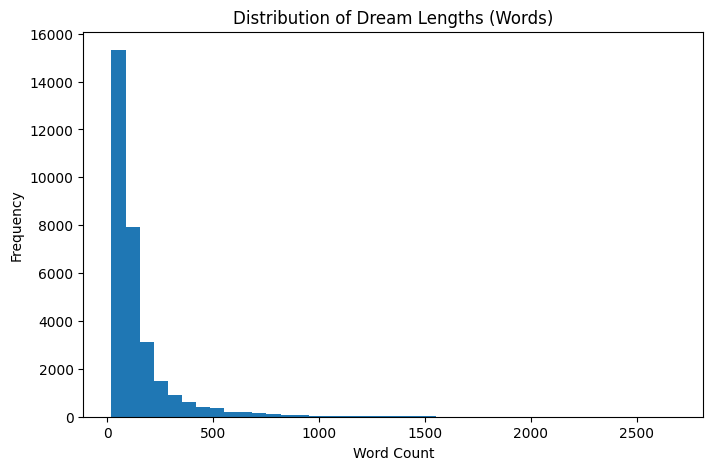

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df_model["word_count"], bins=40)
plt.title("Distribution of Dream Lengths (Words)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

This helps characterize narrative complexity and variability. Later, we can compare dream length by archetype.

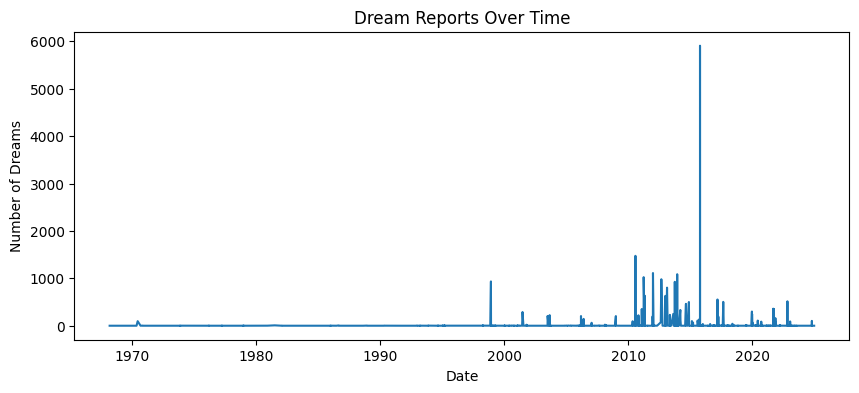

In [16]:
df_model["date"] = pd.to_datetime(df_model["date"], errors="coerce")

dreams_per_day = df_model.groupby(df_model["date"].dt.date).size()

plt.figure(figsize=(10, 4))
dreams_per_day.plot()
plt.title("Dream Reports Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Dreams")
plt.show()

In [17]:
dreams_per_person = df_model["participant_id"].value_counts()

dreams_per_person.describe()

count    8756.000000
mean        3.549680
std        55.808594
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max      4878.000000
Name: count, dtype: float64

In [18]:
dreams_per_person.head()

participant_id
Melvin                      4878
Lucille                      935
KB                           713
tanya1:tanya                 504
jasmine_journala:jasmine     333
Name: count, dtype: int64

This dataset appears longitudinal, meaning some participants record multiple dreams over time, this could prove valuable for later analysis.

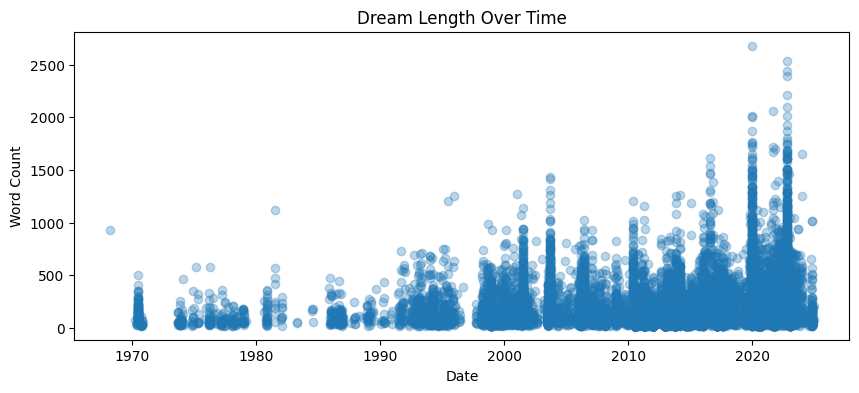

In [19]:
plt.figure(figsize=(10, 4))
plt.scatter(df_model["date"], df_model["word_count"], alpha=0.3)
plt.title("Dream Length Over Time")
plt.xlabel("Date")
plt.ylabel("Word Count")
plt.show()

In [20]:
df_model["text"].sample(5, random_state=42).tolist()

['Flying in an open cockpit WW1 era biplane, engaged in a dogfight. I eventually lost the battle and had to bail out of the plane at very high altitude without a parachute. My brother jumped out of his plane also sans parachute to show me that we could fly (without the planes) and were in no danger of falling.',
 "I dreamed that three other girls and myself were being held in this large building by a gangster. He had much equipment for his gang, guns, lens, etc., and we kept destroying them. He became very angry, but did not kill us. He could not let us go because we knew so much. I managed to find a way to escape and the four of us looked for a place to hide. We came to Clarence Brown's furniture store. I thought this would be an excellent place since one of the girls last names is Brown. They were having a large party at the store and we had to tell just whom we came to see. I told the girl at the desk I wanted to see Clarence Brown and she replied he's been dead since 1863. She imme

Manual inspection confirms:
- narrative structure
- emotional richness
- surreal transitions

This validates suitability for NLP + clustering

In [21]:
MODEL_NAME = "all-MiniLM-L6-v2"
embed_model = SentenceTransformer(MODEL_NAME)

texts = df_model["clean_text"].tolist()

embeddings = embed_model.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

embeddings.shape

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\jebri\Desktop\Coding\Projects\DTSC 4000\.venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jebri\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/975 [00:00<?, ?it/s]

(31200, 384)

SentenceTransformer embeddings: turns each dream into a vector of meaning, which is great for clustering and the UMAP dream universe map

Each dream becomes a numerric vector representing meaning. Now we can cluster dreams based on semantic similarity.

In [24]:
from sklearn.preprocessing import normalize
embeddings = normalize(embeddings)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

labels = clusterer.fit_predict(embeddings)
df_model["cluster_embed"] = labels

df_model["cluster_embed"].value_counts().head(20)

cluster_embed
-1    20964
 0    10205
 1       31
Name: count, dtype: int64

- 20964 dreams are not part of a dense cluster
- 10205 dreams form one massive extremely dense cluster
- 31 dreams form a small but very tight cluster

The dataset contains one dominant highly similar "everyday dream" style, and a huge amount of individual variation outside it.

These 10k dreams are similar enough to confidently group together. Everything else is either too unique or spread out.

But, for our goal we want multiple interpretable archetypes and not just one giant cluster and noise (-1 is the noise cluster)

In [ ]:
# We will reduce embeddings to lower-dimensional space
umap_reducer = umap.UMAP(
    n_neighbors=20,
    n_components=10,   # This is important
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

embeddings_umap = umap_reducer.fit_transform(embeddings)

embeddings_umap.shape

c:\Users\jebri\Desktop\Coding\Projects\DTSC 4000\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(31200, 10)

In [26]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

labels = clusterer.fit_predict(embeddings_umap)
df_model["cluster_embed"] = labels

df_model["cluster_embed"].value_counts().head(20)

cluster_embed
-1     19299
 46      955
 92      586
 42      565
 38      529
 45      484
 78      460
 62      418
 56      414
 59      414
 30      397
 91      342
 2       323
 79      306
 36      261
 57      203
 87      196
 41      183
 82      179
 21      171
Name: count, dtype: int64

It is totatly expected to have noise:
- Very unqiue dreams
- Hybrids of multiple themes
- Weakly structured narratives
This supports our thesis that dreams are chaotic but not entirely.

And we have multiple strong clusters now:
- Dozens of clusters
- Sizes in the 150-1000 range
- Perfect scale for dream archetypes
The patterns are statistically dense semantic themes.


Initial clustering on raw embeddings revealed only the most dominant dream structure. By applying dimensionality reduction before density-based clustering, we were able to uncover finer-grained archetypes that were otherwise obscured

c:\Users\jebri\Desktop\Coding\Projects\DTSC 4000\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


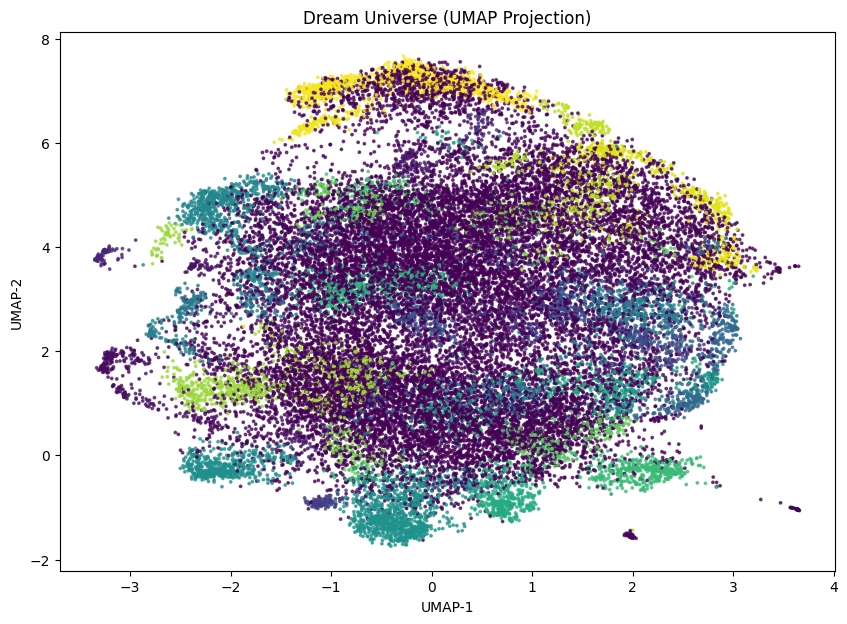

In [27]:
# 2D UMAP for visualization only
umap_2d = umap.UMAP(
    n_neighbors=20,
    n_components=2,
    min_dist=0.1,
    metric="cosine",
    random_state=42
).fit_transform(embeddings)

df_model["x"] = umap_2d[:, 0]
df_model["y"] = umap_2d[:, 1]

plt.figure(figsize=(10, 7))
plt.scatter(
    df_model["x"],
    df_model["y"],
    c=df_model["cluster_embed"],
    s=3,
    alpha=0.7
)
plt.title("Dream Universe (UMAP Projection)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [28]:
top_clusters = (
    df_model["cluster_embed"]
    .value_counts()
    .drop(-1)
    .head(8)
    .index
    .tolist()
)

top_clusters

[46, 92, 42, 38, 45, 78, 62, 56]

In [29]:
def cluster_keywords(cluster_id, n=12):
    texts = df_model.loc[
        df_model["cluster_embed"] == cluster_id,
        "clean_text"
    ]
    vec = TfidfVectorizer(max_features=5000)
    X = vec.fit_transform(texts)
    means = np.asarray(X.mean(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    return vocab[means.argsort()[::-1][:n]].tolist()

for c in top_clusters:
    print("=" * 70)
    print(f"Cluster {c} | size={(df_model['cluster_embed']==c).sum()}")
    print("Keywords:", cluster_keywords(c))

Cluster 46 | size=955
Keywords: ['dream', 'died', 'mother', 'father', 'remember', 'dad', 'years', 'mom', 'away', 'dead', 'dreamed', 'passed']
Cluster 92 | size=586
Keywords: ['one', 'like', 'get', 'house', 'back', 'see', 'people', 'going', 'there', 'guy', 'think', 'little']
Cluster 42 | size=565
Keywords: ['class', 'school', 'one', 'teacher', 'get', 'back', 'students', 'classroom', 'like', 'going', 'time', 'something']
Cluster 38 | size=529
Keywords: ['dog', 'cat', 'house', 'one', 'get', 'like', 'see', 'back', 'dogs', 'trying', 'cats', 'around']
Cluster 45 | size=484
Keywords: ['work', 'dream', 'job', 'working', 'dreamed', 'get', 'people', 'dreams', 'time', 'remember', 'yes', 'retired']
Cluster 78 | size=460
Keywords: ['school', 'dream', 'class', 'remember', 'like', 'one', 'test', 'going', 'exam', 'teacher', 'dreamed', 'back']
Cluster 62 | size=418
Keywords: ['dream', 'said', 'like', 'one', 'saw', 'god', 'time', 'people', 'see', 'church', 'jesus', 'came']
Cluster 56 | size=414
Keywords

In [30]:
def show_examples(cluster_id, n=3):
    examples = (
        df_model[df_model["cluster_embed"] == cluster_id]
        .sample(n=n, random_state=42)["text"]
        .tolist()
    )
    for ex in examples:
        print("-", ex[:350].replace("\n", " "), "...\n")

for c in top_clusters[:3]:
    print("\n" + "#" * 80)
    print(f"CLUSTER {c}")
    show_examples(c)


################################################################################
CLUSTER 46
- I had a dream a few weeks ago that I was going to visit my Dad and I felt anxious about it and never ended seeing him. ...

- My father was visiting to share some life lessons about dealing with business negociations. He had a polo shirt and slacks on.  In the dream, I knew he had passed away and been interred but during the dream, he was active at the home we grew up in. ...

- One night when I was about 15 years old I had a dream that I was at home and everyone was sleeping when we got a phone call saying that my grandfather had died. The next morning after I had woken up from the dream I went downstairs and my mother was crying. My grandfather had been put into the hospital after a heart attack but luckily he made it th ...


################################################################################
CLUSTER 92
- I am with my friend, Aila, who is Native American and also keeps incorpo